In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def sample_function(x, y):
    return y**2+1

In [55]:
def euler(num_steps, h, x0, y0, f_xy):
    x = np.array([x0])
    y = np.array([y0])
    for i in range(num_steps):
        x = np.append(x, x[-1] + h)
        y = np.append(y, y[-1]+h*f_xy(x[-1],y[-1]))

    return x, y


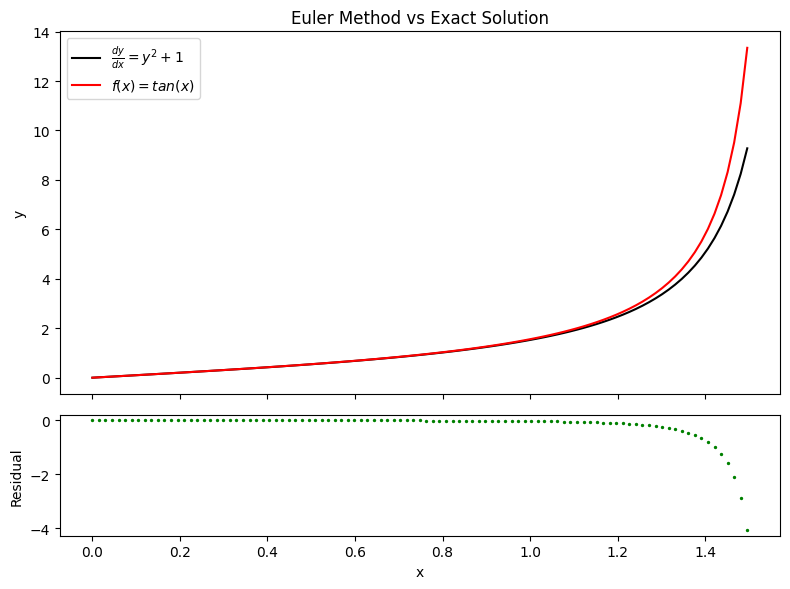

In [76]:
x_eu, y_eu = euler(100,(np.pi/2.1)/100,0,0,sample_function)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(x_eu,y_eu, color='black', label=r'$\frac{dy}{dx}=y^2+1$')
ax1.plot(x_eu,np.tan(x_eu), color='red', label=r'$f(x)=tan(x)$')
ax1.set_ylabel('y')
ax1.legend()
ax1.set_title("Euler Method vs Exact Solution")

ax2.scatter(x_eu, y_eu-np.tan(x_eu), color='green', s=2)
ax2.set_xlabel('x')
ax2.set_ylabel('Residual')

plt.tight_layout()

plt.savefig('Euler')

In [58]:
def runge_kutta(num_steps, h, x0, y0, f_xy):
    x = np.array([x0])
    y = np.array([y0])

    k1 = np.array([f_xy(x0,y0)])
    k2 = np.array([f_xy(x0+h/2, y0 + k1[0] * h/2)])
    k3 = np.array([f_xy(x0+h/2, y0 + k2[0] * h/2)])
    k4 = np.array([f_xy(x0+h, y0 + k3[0] * h)])
    
    for i in range(num_steps):
        x = np.append(x, x[-1]+h)
        y = np.append(y, y[-1] + h/6 * (k1[-1] + 2*k2[-1] + 2*k3[-1] + k4[-1]))

        k1 = np.append(k1, f_xy(x[-1],y[-1]))
        k2 = np.append(k2, f_xy(x[-1]+h/2, y[-1] + k1[-1] * h/2))
        k3 = np.append(k3, f_xy(x[-1]+h/2, y[-1] + k2[-1] * h/2))
        k4 = np.append(k4, f_xy(x[-1]+h, y[-1] + k3[-1] * h))

    return x, y, k1, k2, k3, k4


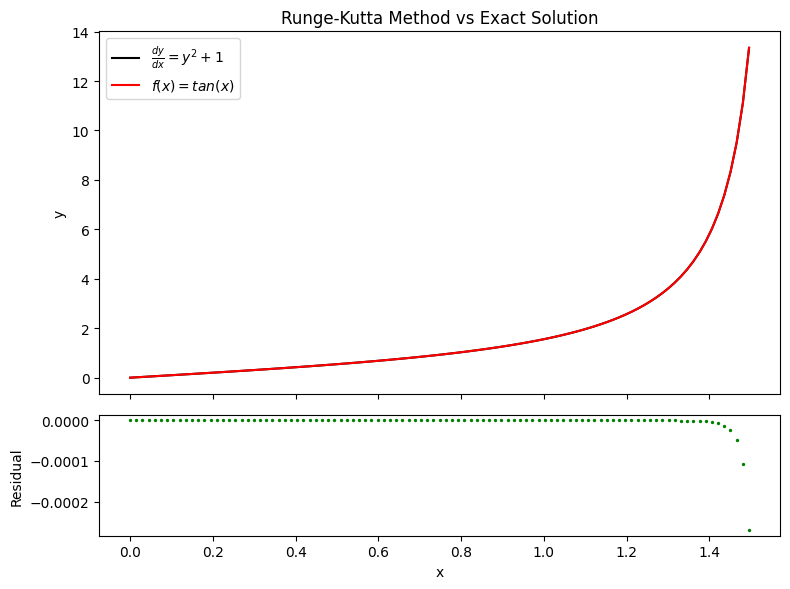

In [105]:
x_rk, y_rk, _,_,_,_ = runge_kutta(100,(np.pi/2.1)/100,0,0,sample_function)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(x_rk,y_rk, color='black', label=r'$\frac{dy}{dx}=y^2+1$')
ax1.plot(x_rk,np.tan(x_rk), color='red', label=r'$f(x)=tan(x)$')
ax1.set_ylabel('y')
ax1.legend()
ax1.set_title("Runge-Kutta Method vs Exact Solution")

ax2.scatter(x_rk, y_rk-np.tan(x_rk), color='green', s=2)
ax2.set_xlabel('x')
ax2.set_ylabel('Residual')

plt.tight_layout()

plt.savefig('Runge-Kutta')

In [119]:
num_steps = np.linspace(5,500,100).astype(int)
rk_stdev = np.array([])
rk_diff = np.array([])

_, y_rk_r, _,_,_,_ = runge_kutta(1000,(np.pi/2.1)/1000,0,0,sample_function)

for n in num_steps:
    x_rk, y_rk,_,_,_,_ = runge_kutta(n,(np.pi/2.1)/n,0,0,sample_function)

    rk_stdev = np.append(rk_stdev, np.std(y_rk-np.tan(x_rk)))
    rk_diff = np.append(rk_diff, 1-y_rk[-1]/y_rk_r[-1])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(x_rk,y_rk, color='black', label=r'$\frac{dy}{dx}=y^2+1$')
    ax1.plot(x_rk,np.tan(x_rk), color='red', label=r'$f(x)=tan(x)$')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.set_title(f"Runge-Kutta Method, {n} steps ")

    ax2.scatter(x_rk, y_rk-np.tan(x_rk), color='green', s=2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('Residual')

    plt.tight_layout()
    plt.close()
    #plt.show()


In [120]:
eu_stdev = np.array([])
eu_diff = np.array([])

_, y_eu_r= euler(1000,(np.pi/2.1)/1000,0,0,sample_function)

for n in num_steps:
    x_eu, y_eu = euler(n,(np.pi/2.1)/n,0,0,sample_function)

    eu_stdev = np.append(eu_stdev, np.std(y_eu-np.tan(x_eu)))
    eu_diff = np.append(eu_diff, 1-y_eu[-1]/y_eu_r[-1])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(x_eu,y_eu, color='black', label=r'$\frac{dy}{dx}=y^2+1$')
    ax1.plot(x_eu,np.tan(x_eu), color='red', label=r'$f(x)=tan(x)$')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.set_title(f"Euler Method, {n} steps ")

    ax2.scatter(x_eu, y_eu-np.tan(x_eu), color='green', s=2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('Residual')

    plt.tight_layout()
    plt.close()
    #plt.show()


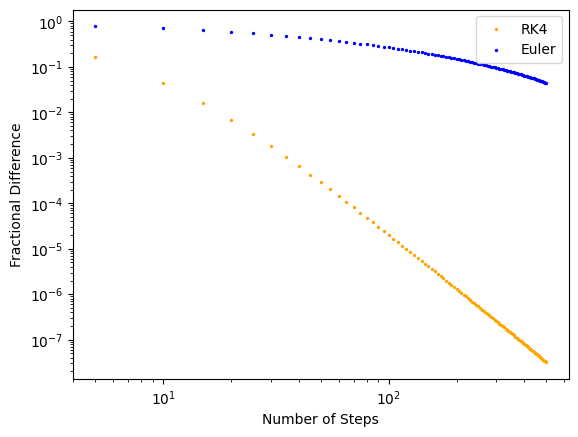

In [127]:
plt.scatter(num_steps, rk_diff, color='orange', label='RK4', s=2)
plt.scatter(num_steps, eu_diff, color='blue', label='Euler', s=2)

plt.xlabel('Number of Steps')
plt.ylabel('Fractional Difference')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.savefig('frac_diff')

In [151]:
velocities = np.linspace(0,40000,200)
m_h = 1.6735e-27
k = 1.38065e-23
T_star = 10000
def max_bolt(v, m, T):
    fv = (m/(2*np.pi*k*T))**(3/2) * 4*np.pi*v**2 * np.exp(-(m*v**2)/(2*k*T))
    return fv


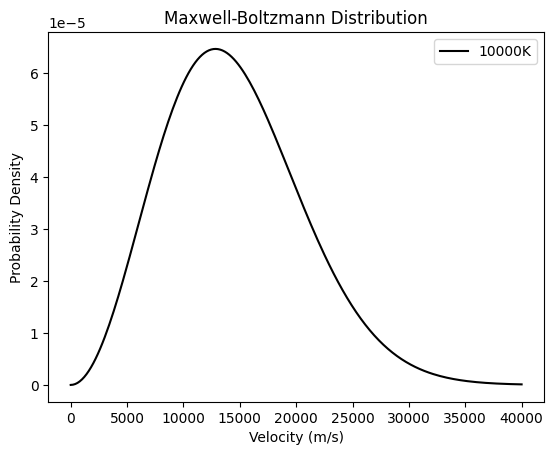

In [179]:
fv = max_bolt(velocities, m_h, T_star)
plt.plot(velocities, fv, color='black', label='10000K')

plt.title('Maxwell-Boltzmann Distribution')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Probability Density')

plt.legend()
plt.savefig('MB_star')

In [185]:
E_12  = 1.63e-18
v_min = np.sqrt(2*E_12 / m_h)

vel_int = np.linspace(v_min, 1000000, 1000000)

#Integral function by taking height of boxes to avg height of endpoints
def ymidpoint_int(x, fx):
    area = 0
    for i in range(len(x)-1):
        dx = x[i+1]-x[i]
        h_i = ( fx[i+1] + fx[i] ) /2

        area += dx * h_i
    
    return area
    
ymidpoint_int(vel_int, max_bolt(vel_int, m_h, T_star))

np.float64(3.009936950757039e-05)

In [186]:
area_ref = ymidpoint_int(vel_int, max_bolt(vel_int, m_h, T_star))

In [231]:
steps = np.linspace(500,500000,100).astype(int)
error_step = np.array([])
for n in steps:
    x_n = np.linspace(v_min, 1000000, n)
    area_n = ymidpoint_int(x_n, max_bolt(x_n, m_h, T_star))
    error_step = np.append(error_step, area_n - area_ref)

v_max = np.linspace(50000, 5000000, 100)
error_vmax = np.array([])
for v in v_max:
    x_n = np.linspace(v_min, v, np.round((v-v_min)/10).astype(int))
    area_n = ymidpoint_int(x_n, max_bolt(x_n, m_h, T_star))
    error_vmax = np.append(error_vmax, area_n - area_ref)


In [232]:
error_step

array([2.28862657e-06, 1.87654137e-08, 5.14387744e-09, 2.35913966e-09,
       1.34825203e-09, 8.71017666e-10, 6.08646306e-10, 4.49080374e-10,
       3.44901622e-10, 2.73128728e-10, 2.21611352e-10, 1.83379833e-10,
       1.54224486e-10, 1.31492598e-10, 1.13420327e-10, 9.88214290e-11,
       8.68552073e-11, 7.69284123e-11, 6.85994938e-11, 6.15457012e-11,
       5.55171582e-11, 5.03263532e-11, 4.58240902e-11, 4.18930371e-11,
       3.84418130e-11, 3.53942283e-11, 3.26907397e-11, 3.02805099e-11,
       2.81234333e-11, 2.61845177e-11, 2.44359766e-11, 2.28530716e-11,
       2.14160763e-11, 2.01070904e-11, 1.89118092e-11, 1.78172211e-11,
       1.68121343e-11, 1.58874078e-11, 1.50343679e-11, 1.42460970e-11,
       1.35159181e-11, 1.28385218e-11, 1.22086974e-11, 1.16223195e-11,
       1.10753749e-11, 1.05643071e-11, 1.00862319e-11, 9.63819486e-12,
       9.21789462e-12, 8.82293481e-12, 8.45146311e-12, 8.10151694e-12,
       7.77159332e-12, 7.46007211e-12, 7.16572418e-12, 6.88720208e-12,
      

In [233]:
error_vmax

array([-1.19173907e-06,  6.25889445e-11,  6.25743127e-11,  6.25690697e-11,
        6.25663738e-11,  6.25647317e-11,  6.25636264e-11,  6.25628318e-11,
        6.25622329e-11,  6.25617653e-11,  6.25613905e-11,  6.25610828e-11,
        6.25608260e-11,  6.25606083e-11,  6.25604215e-11,  6.25602594e-11,
        6.25601175e-11,  6.25599921e-11,  6.25598805e-11,  6.25597806e-11,
        6.25596907e-11,  6.25596093e-11,  6.25595353e-11,  6.25594675e-11,
        6.25594054e-11,  6.25593484e-11,  6.25592956e-11,  6.25592470e-11,
        6.25592014e-11,  6.25591592e-11,  6.25591197e-11,  6.25590828e-11,
        6.25590482e-11,  6.25590155e-11,  6.25589849e-11,  6.25589561e-11,
        6.25589288e-11,  6.25589031e-11,  6.25588786e-11,  6.25588554e-11,
        6.25588334e-11,  6.25588124e-11,  6.25587924e-11,  6.25587734e-11,
        6.25587552e-11,  6.25587378e-11,  6.25587211e-11,  6.25587052e-11,
        6.25586900e-11,  6.25586754e-11,  6.25586614e-11,  6.25586479e-11,
        6.25586348e-11,  

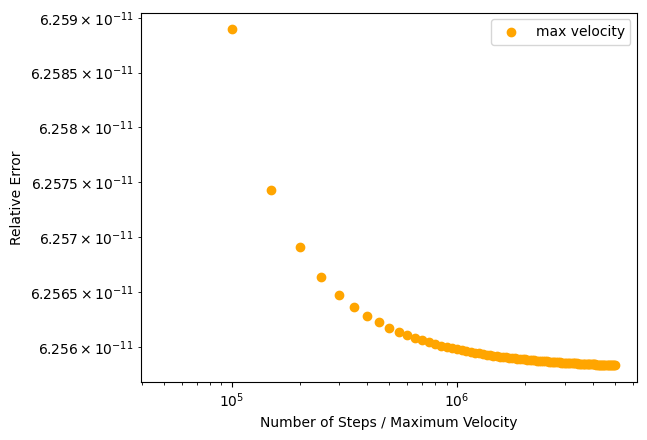

In [240]:
#plt.scatter(steps, error_step, label='step sizes')
plt.scatter(v_max, error_vmax, color = 'orange', label= 'max velocity')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.xlabel('Number of Steps / Maximum Velocity')
plt.ylabel('Relative Error')
plt.savefig('vel_err')